## APPLIED STATISTICS

### Turma 16DTSR

#### Trabalho prático usando o Python
### Técnica Supervisionada: Variável Target quantitativa

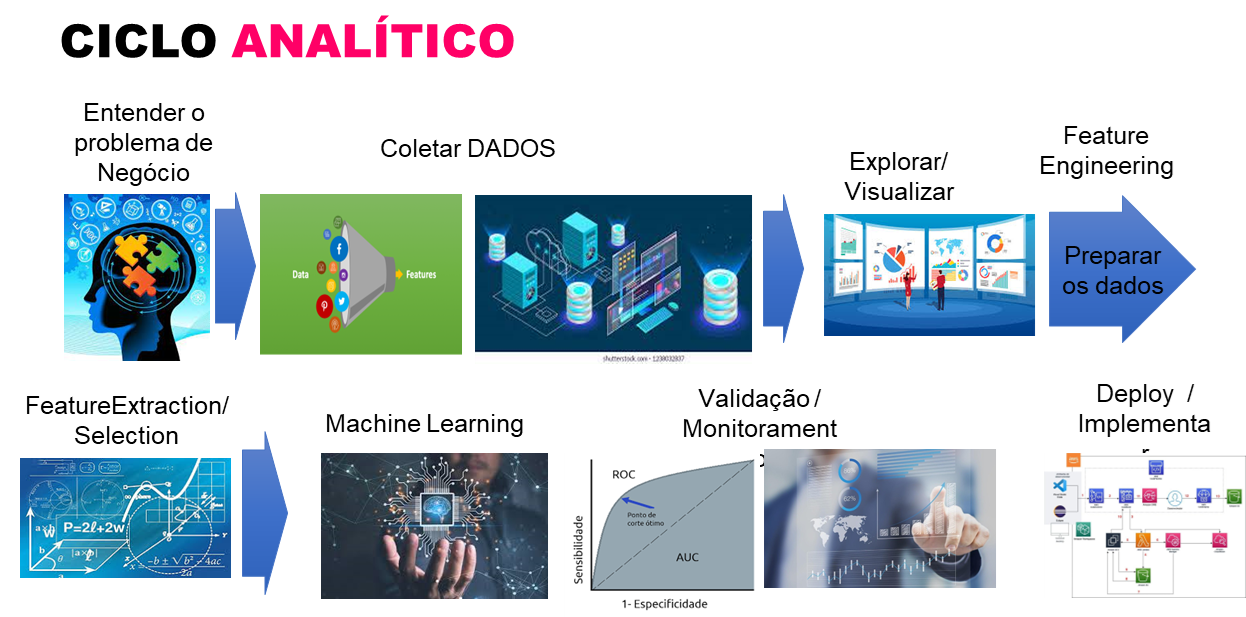

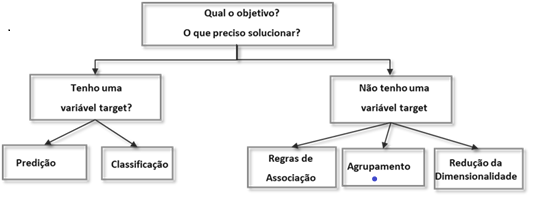

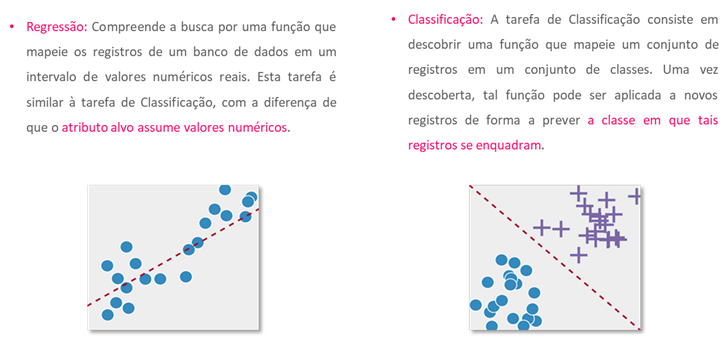

###    REGRESSÃO LINEAR MÚLTIPLA
    Exemplo: Estimar o valor de venda de um imóvel em função das características do imóvel: área em m2, quantidade de dormitórios,
    quantidade de suítes, andar, varanda gourmet, área verde nas proximidades, distância de metrô ou transporte público, etc

Estimar o valor de imóveis a partir de características  disponibilizadas:

Variáveis:

Valor do Imóvel [Valor]: Valor do imóvel

Área [Area]: Utilizou-se a área total do apartamento em metros quadrados;

Idade Aparente [IA]: Idade aparente em anos

Andar [Andar]: É o número do andar do apartamento;

Suítes [Suites]: Número de suítes;

Vista Panorâmica [Vista]: A variável ambiental vista panorâmica é uma variável dicotômica: se o apartamento tiver vista panorâmica a variável vista assume valor igual a 1, se não tiver vista seu valor será 0;

Sem Ruído na rua [Sem Ruído]: A variável ambiental Sem Ruído é uma variável dicotômica: se o apartamento está localizado em rua onde o nível de ruído está abaixo do que é considerado não prejudicial terá valor 1, se tiver nível de ruído acima terá valor 0;

Distância a Avenida Beira Mar [Dist. BM]: A distância é medida em metros, pelo eixo da rua do prédio onde os apartamentos estão localizados até a Avenida Beira Mar;

Área Verde a uma distância de 200 metros [AV 200m]: Área verde a uma distância de 200 metros assume valor igual a 1, ultrapassando 200 metros assume valor 0.

In [1]:
# importanto as bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats



import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [4]:
# lendo a base de dados
imoveis= pd.read_excel(r'Date/Arquivo_Valorizacao_Ambiental.xlsx')

FileNotFoundError: [Errno 2] No such file or directory: 'Date/Arquivo_Valorizacao_Ambiental.xlsx'

In [ ]:
# visualizando alguns dados
imoveis.head()

In [ ]:
# visualizando formatos das variáveis
imoveis.info()

In [ ]:
# Avaliando a quantidade de NA´s (missing)
pd.DataFrame(zip(imoveis.isnull().sum(),imoveis.isnull().sum()/len(imoveis)), columns=['Count', 'Proportion'], index=imoveis.columns)


In [ ]:
# descritivo das variáveis: medidas resumo
imoveis.describe().round(2)


In [ ]:
# Histograma da variável Valor  Variável target / Variável Dependente / Supervisionar

plt.hist(imoveis['Valor'], bins=20)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title('Histograma Valor');



In [ ]:
# Outra opção para variáveis quantitativas Boxplot: para visualizar Outliers
features = ['Valor','Area','IA','DistBM','Suites']
fig,axs=plt.subplots(nrows=1, ncols=5, figsize=(18,10))
for col, ax in zip(features[0:], axs.ravel()):
    x=imoveis.loc[:, col]
    sb.boxplot(x, ax=ax, orient='v')
    ax.set_title(col)  # Esta linha adiciona o título ao gráfico
    ax.set_xlabel('')  # Esta linha remove o rótulo do eixo x, que pode ser redundante
    plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10,right=0.95,hspace=0.25,wspace=0.4)

In [ ]:
# avaliando a distribuicaoo de cada variavel numérica

plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)
fig = imoveis['Valor'].hist(bins=20)
fig.set_xlabel('Valor ')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 2)
fig = imoveis['AV100m'].hist(bins=20)
fig.set_xlabel('AV100m')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 3)
fig = imoveis['IA'].hist(bins=20)
fig.set_xlabel('IA')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 4)
fig = imoveis['Andar'].hist(bins=20)
fig.set_xlabel('Andar')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 5)
fig = imoveis['Suites'].hist(bins=20)
fig.set_xlabel('Suites')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 6)
fig = imoveis['DistBM'].hist(bins=20)
fig.set_xlabel('DistBM')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 7)
fig = imoveis['Semruido'].hist(bins=20)
fig.set_xlabel('Semruido ')
fig.set_ylabel('Número de casos')

plt.subplot(4, 2, 8)
fig = imoveis['Area'].hist(bins=20)
fig.set_xlabel('Area ')
fig.set_ylabel('Número de casos')


In [ ]:
# Importante nessa etapa é avaliar se tem alguma variável com presença de outliers ou daados extremos
# Antes de ir para a correlação avaliar o que fazer!!!!!!!!!!!corrigir, eliminar....

In [ ]:
# excluindo variáveis que não são necessárias
imoveis = imoveis.drop(['Ordem'], axis = 1)
imoveis.head()

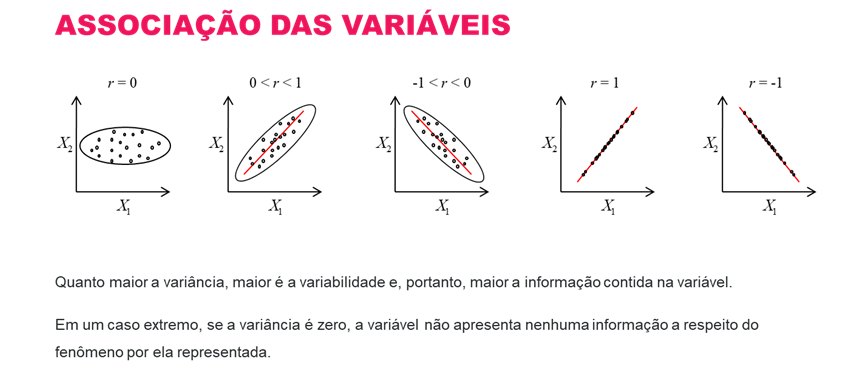

In [ ]:
# Correlação de Pearson - quando as variáveis são núméricas quantitativas
# ρ = 0,9 a 1 (positivo ou negativo): correlação muito forte;
# ρ = 0,7 a 0,9 (positivo ou negativo): correlação forte;
# ρ = 0,5 a 0,7 (positivo ou negativo): correlação moderada;
# ρ = 0,3 a 0,5 (positivo ou negativo): correlação fraca;
# ρ = 0 a 0,3 (positivo ou negativo): não possui correlação.

imoveis.corr().round(2)

In [ ]:
# Correlação de Pearson - quando as variáveis são núméricas quantitativas
corr = imoveis.corr(method='pearson')
corr

#### Observação muito cuidado com a análise de correlação em variáveis que são do tipo categórica
####  e que foram transformadas m variáveis numéricas (tipo dummy)

In [ ]:
correlation = imoveis.corr()
plt.figure(figsize=(10,4))
#sb.heatmap(correlation, vmax=1, square=True,annot=True,cmap='viridis',fmt=".1f", linewidths=.6)
sb.heatmap(correlation, annot=True,fmt=".1f", linewidths=.6)
plt.title('Correlation between different features');


### Na análise descritiva sempre utilizar a variável Target - de acordo com o objetivo

In [ ]:
# gráfico quando a variável preditora quantitativa

# Gráfico de dispersão ou scatterplot
plt.scatter('Area', 'Valor', data=imoveis)
plt.xlabel("Area em m2")
plt.ylabel("Valor")
plt.title(" Scatter plot Valor versus Area em m2");

Percebam que quanto maior o área do imovel maior o valor em média....

In [ ]:
# Variáveis Preditoras/Independentes quantitativas com a variável Target


plt.figure(figsize=(24,20))


plt.subplot(4, 2, 1)

ax1 = plt.scatter(imoveis['Area'], imoveis['Valor'], marker='o');
plt.title('Análise: Valor vs Area')
plt.ylabel('Valor')
plt.xlabel('Area')

plt.subplot(4, 2, 2)

ax2 = plt.scatter(imoveis['IA'], imoveis['Valor'], marker='o');
plt.title('Análise: Valor vs Idade Aparente')
plt.ylabel('Valor')
plt.xlabel('Idade Aparente')


plt.subplot(4, 2, 3)

ax3 = plt.scatter(imoveis['DistBM'], imoveis['Valor'], marker='o');
plt.title('Análise: Valor vs Distancia Beira Mar')
plt.ylabel('Valor')
plt.xlabel('DistBM')


plt.subplot(4, 2, 4)

ax4 = plt.scatter(imoveis['Suites'], imoveis['Valor'], marker='o');
plt.title('Análise: Valor vs Suites')
plt.ylabel('Valor')
plt.xlabel('Suites')

In [ ]:
# Variáveis qualitativa com a variável Target

# Boxplot da variável Valor versus a variável Vista
sb.boxplot(x='Vista', y='Valor', data=imoveis, palette='hls');

Veja no gráfico acima que os valores dos imoveis que possuem Vista Panorâmica são: maiores..............

In [ ]:
# Boxplot da variável Valor versus a variável Semruido
sb.boxplot(x='Semruido', y='Valor', data=imoveis, palette='hls')

In [ ]:
# Boxplot da variável Valor versus a variável AV100m
sb.boxplot(x='AV100m', y='Valor', data=imoveis, palette='hls')

#### Uma observação:
     Nesta base que estamos utilizando as variáveis categóricas já foram transformadas em variáveis númericas do tipo dummy


In [ ]:
# Teste qui-quadrado é utilizado para descobrir associação entre duas variáveis qualitativas
# transformar a variável Valor do Imovel em qualitativa --> faixa valor (qualitativa ordinal) vs Semruido(qualitativa nominal)
# criar a faixa_vlr você usar os quartis

In [ ]:
# Criar uma variável categórica
Q1 =  np.percentile(imoveis['Valor'], 25)
Q2 =  np.percentile(imoveis['Valor'], 50)
Q3 =  np.percentile(imoveis['Valor'], 75)
maximo = max(imoveis['Valor'])
print(Q1, Q2, Q3, maximo)


In [ ]:
imoveis.loc[(imoveis.Valor >= 0) & (imoveis.Valor <= Q1), 'fx_total']=1.0
imoveis.loc[(imoveis.Valor > Q1) & (imoveis.Valor <= Q2), 'fx_total']=2.0
imoveis.loc[(imoveis.Valor>  Q2)  & (imoveis.Valor <=Q3), 'fx_total']=3.0
imoveis.loc[(imoveis.Valor >  Q3) & (imoveis.Valor <= maximo), 'fx_total']=4.0

In [ ]:
# Boxplot da variável Valor versus a variável categoria de valor
sb.boxplot(x='fx_total', y='Valor', data=imoveis, palette='hls');

In [ ]:
imoveis.info()

In [ ]:
# crosstab tabela cruzada entre duas variáveis qualitativas

table = pd.crosstab(imoveis.fx_total,imoveis.Semruido)

In [ ]:
print(table)

In [ ]:
# crosstab tabela cruzada entre duas variáveis qualitativas com total

pd.crosstab(imoveis.fx_total,imoveis.Semruido, margins=True)

### Os valores encontrados na tabela acima são os valores observados

### E os valores esperados?

#### eu espero que na condição da hipótese nula ser verdadeira, em casa faixa de valor
#### eu tenha a mesma proporção de imóveis em região com ruído e sem ruído

In [ ]:
# Uma variável categórica  sem_ruído
# Qual a proporção de imóveis em locais sem/com ruído nessa base

(imoveis.Semruido.value_counts() / imoveis.shape[0]) * 100

In [ ]:
# Calculando na faixa 1
43*0.58


In [ ]:
43-25

#### Na hipótese de não ter diferença entre a variável "faixas de valores" e a variável "Sem ruído"
#### espera-se que o percentual de ter ou não ruído seja a mesma do total para cada faixa de valor

####   Teste de hipótese:
    H0: não há relação entre valor e ruído
    H1: há relação entre valor e ruído
    α = 0,05 (5%)



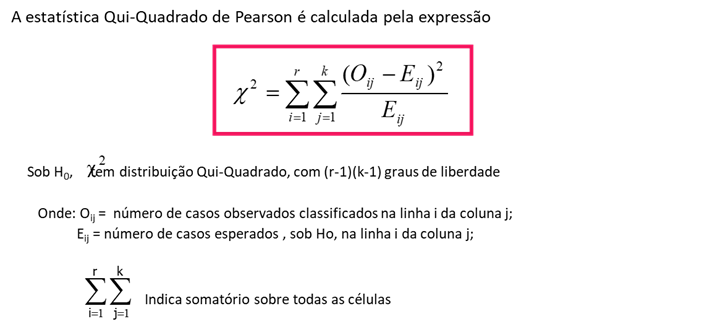

In [ ]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2
!pip install researchpy
import researchpy

In [ ]:
results1 = researchpy.crosstab(imoveis['fx_total'],imoveis['Semruido'], test='chi-square')

In [ ]:
# Resultado Teste chi-Quadrado
#   H0: não há relação entre valor e ruído
#   H1: há relação entre valor e ruído
#   α = 0,05 (5%)


results1

In [ ]:
0.58*43

In [ ]:
43-25


### o p-value no teste chiquadrado se for menor que 0.05 não aceita-se Ho

In [ ]:
# Resultado Teste chi-Quadrado
#   H0: não há relação entre valor e ter vista
#   H1: há relação entre valor e ter vista
#   α = 0,05 (5%)

results2 = researchpy.crosstab(imoveis['fx_total'],imoveis['Vista'], test='chi-square')
results2


In [ ]:
# Resultado Teste chi-Quadrado
#   H0: não há relação entre valor e area verde
#   H1: há relação entre valor e ter área verde
#   α = 0,05 (5%)


results3 = researchpy.crosstab(imoveis['fx_total'],imoveis['AV100m'], test='chi-square')
results3

####  Caso tenha uma variável preditora quantitativa que queira criar categorias

In [ ]:
imoveis.loc[(imoveis.DistBM >= 0) & (imoveis.DistBM <= 600), 'fx_DistBM']=0.0

imoveis.loc[(imoveis.DistBM >  600) & (imoveis.DistBM <= np.max(imoveis['DistBM'])), 'fx_DistBM']=1.0

In [ ]:
# Boxplot da variável Valor versus a variável categoria de valor
sb.boxplot(x='fx_DistBM', y='DistBM', data=imoveis)

In [ ]:
# Boxplot da variável Valor versus a variável categoria de valor
sb.boxplot(x='fx_DistBM', y='Valor', data=imoveis);

In [ ]:
# Resultado Teste chi-Quadrado
#   H0: não há relação entre valor e distancia beira mar
#   H1: há relação entre valor e distancia beira mar
#   α = 0,05 (5%)

results4 = researchpy.crosstab(imoveis['fx_total'],imoveis['fx_DistBM'], test='chi-square')
results4

Vários Algoritmos pode ser alternativas de resolver problemas com ..................

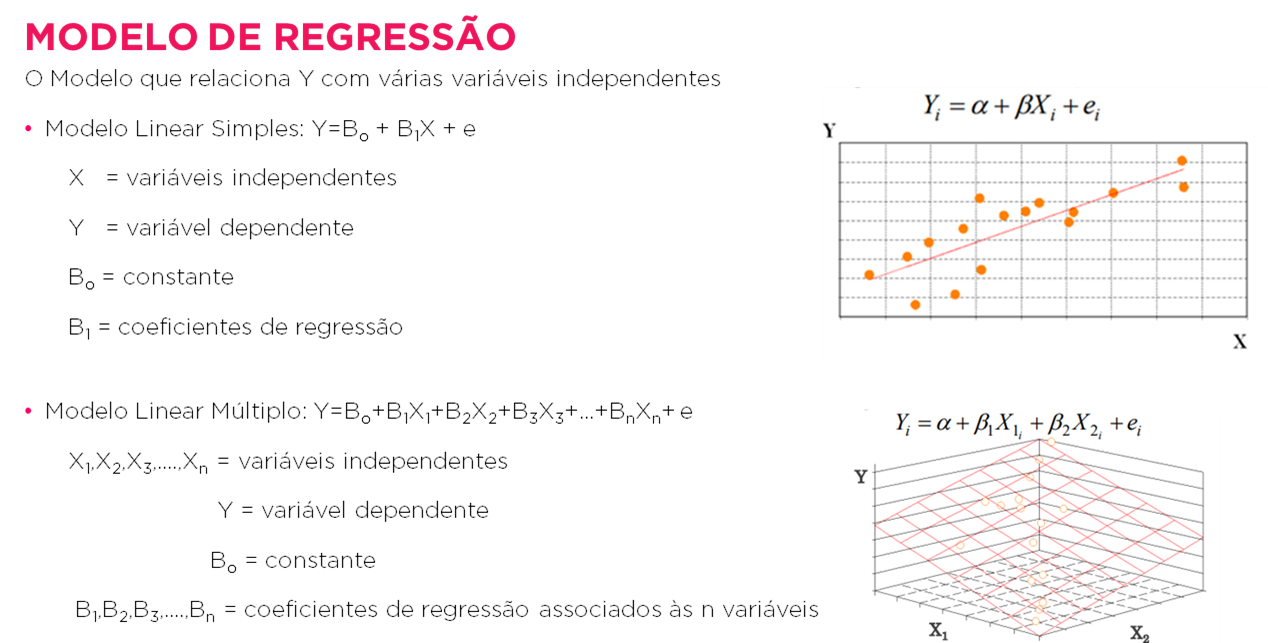

In [ ]:
imoveis.info()

####  Passos após a etapa de pré processamento e preparação da base

In [ ]:

X = imoveis[imoveis.columns[1:9]]

y = imoveis['Valor']

In [ ]:
X

In [ ]:
y

In [ ]:
# Importar as bibliotecas
from sklearn.model_selection import train_test_split

# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 17)

In [ ]:
X_train

In [ ]:
y_train

     Primeira Biblioteca
     
https://www.statsmodels.org/stable/index.html

In [ ]:
# importar bibliotecas
import statsmodels.api as sm
from scipy import stats

### sm.add_constant(X)"

#### É usado para adicionar um termo constante a um conjunto de dados X.

#### Este termo constante é adicionado para permitir que os modelos estimem um termo de interceptação.



#####  Ao ajustar um modelo de regressão linear, se você não incluir explicitamente um termo constante em seus dados, o modelo

##### assumirá que não há interceptação. No entanto, em muitos casos, geralmente há uma interceptação diferente de zero.



##### Ao adicionar um termo constante usando sm.add_constant(X), estamos adicionando uma coluna de 1s ao seu conjunto de dados X,

##### o que permite ao modelo estimar também o termo de interceptação.

In [ ]:
#Modelo de regressão linear múltipla
# regression.linear_model.OLS Ordinary Least Squares

X_ = sm.add_constant(X_train)

X_

In [ ]:
#Modelo de regressão linear múltipla
# regression.linear_model.OLS Ordinary Least Squares


model_OLS = sm.OLS(y_train, X_).fit()

print(model_OLS.summary())




Na análise de regressão os coeficientes (coef)
os coeficientes são estimativas dos parâmetros populacionais reais.
Queremos que essas estimativas de coeficientes sejam as melhores estimativas possíveis!

In [ ]:
# Voltando na base
imoveis.info()

### Selecionando as variáveis significantes

In [ ]:
# Selecionando as variáveis significantes

X_train, X_test, y_train, y_test = train_test_split(imoveis.drop(['Valor', 'DistBM', 'AV100m','fx_total','fx_DistBM'],axis=1),imoveis['Valor'],test_size=0.05, random_state=17)


In [ ]:
X_train

In [ ]:
y_train

In [ ]:
#Modelo de regressão linear múltipla
# regression.linear_model.OLS Ordinary Least Squares

X_ = sm.add_constant(X_train)

model_fim = sm.OLS(y_train, X_).fit()

print(model_fim.summary())



    Na saída da regressão linear as medidas mais importantes para nós neste momento são o R2 ajustado, a estatística de teste F, o p-valor dessa estatística e, caso queiramos comparar diferentes modelos, o log-likelihood, o Akaike Information Criterion (AIC) e o Bayesian Information Criterion (BIC).
    
    A avaliação da qualidade de ajuste da reta de regressão que é obtida atráves de Soma de Quadrados de Resíduos (SQR) e R2 RQuadrado). Também, pode-se usar a estatística F que é usado para testar se pelo menos uma variável preditora possui um coeficiente diferente de zero.
    TESTANDO O MODELO PREDITIVO DE Y
	Ho: B1 = B2 = B3 = ... = Bn
	H1: pelo menos um B não é zero
    
    Coeficiente de Determinação (R2)
    O coeficiente de determinação ou R2, mede a proporção de variabilidade total em Y que pode ser explicada pela reta de regressão linear com as variáveis preditoras, e assume sempre valores de 0 e 1. Se R2 é proximo de 1, indica que uma grande proporção da variabilidade na resposta foi explicada pela regressão e ´quando R2 é próximo de 0 indica que a regressão não explicou grande parte da variabilidade na resposta.

    Neste estudo, R2= 0.805, 81% da variação total do valor do imóvel é explicada pela equação de regressão estimada tendo as variáveis explicativas significativas.

    TESTANDO OS PARÂMETROS:  
     Ho: Bs igual a  0
     H1: Bs # 0
     é calculado a estatistica t para cada variável independente.
     ==> se  P>|t|  (p-value) for <0.05 rejeito a hipótese nula,
         a variável é significante para estimar a variável target.
     

# Vamos ao simulador!!

In [ ]:
# Importar a biblioteca
# Medidas de erro

# Utilizado quando vamos comparar vários modelos

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Calculando o valor predito da variável resposta na amostra treino
y_train_pred = model_fim.predict(X_)


In [ ]:
y_train_pred

Medidas de Desempenho

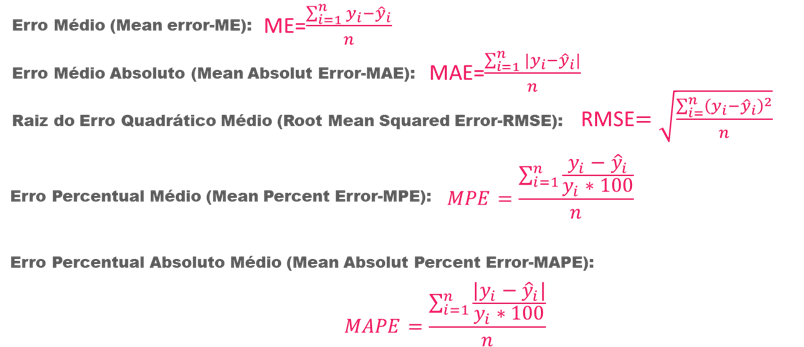

In [ ]:
# Medidas de erro na amostra treino
me1   = round((y_train-y_train_pred).mean(),2)
print('Erro Médio (Mean error-ME):', me1)
mae1  = round((mean_absolute_error(y_train, y_train_pred)),2)
print('Erro Médio Absoluto (Mean Absolut Error-MAE):', mae1)
mse1  =round( (mean_squared_error(y_train, y_train_pred)),2)
print('Erro Quadrático Médio (Mean Squared Error-MSE)::', mse1)
rmse1  = round((np.sqrt(mean_squared_error(y_train, y_train_pred))),2)
print('Raiz do Erro Quadrático Médio (Root Mean Squared Error-RMSE):', rmse1)
mpe1  = round(((y_train - y_train_pred)/y_train).mean(),2)
print('Erro Percentual Médio (Mean Percent Error-MPE):', mpe1)
mape1  =  round((mae1/y_train).mean(),2)
print('Erro Percentual Absoluto Médio (Mean Absolut Percent Error-MAPE):', mape1)

1. RMSE (Raiz do Erro Quadrático Médio)
  Quando erros grandes são muito indesejados e você precisa penalizá-los.
  (+) Utiliza a mesma unidade da variável de resposta, facilitando a interpretação.
  (-) É sensível a outliers (valores discrepantes).

2. MAE (Erro Médio Absoluto)
   Situações onde você deseja uma interpretação direta do erro médio e tem outliers no conjunto de dados.
   (+) Robustez a outliers, tratando todos os erros de forma linear.
   (-) Pode não refletir a gravidade de grandes erros individuais da mesma forma que o RMSE.

3. MAPE (Erro Percentual Médio Absoluto)
   Relatar o desempenho para áreas de negócio, pois expressa o erro em porcentagem (ex: "erro médio de 5%").
   (+) Fácil interpretação e comparação entre diferentes escalas de dados.
   (-) Falha se o valor real for zero.

4. R-quadrado (R² ou Coeficiente de Determinação)
  Melhor para entender quanto da variância dos dados o modelo explica (variação de 0 a 1).
   (+) Permite comparar a qualidade de ajuste entre diferentes modelos.

In [ ]:
list1 = [me1, mae1,mse1,rmse1,mpe1, mape1]

pd.DataFrame({"treino":list1})

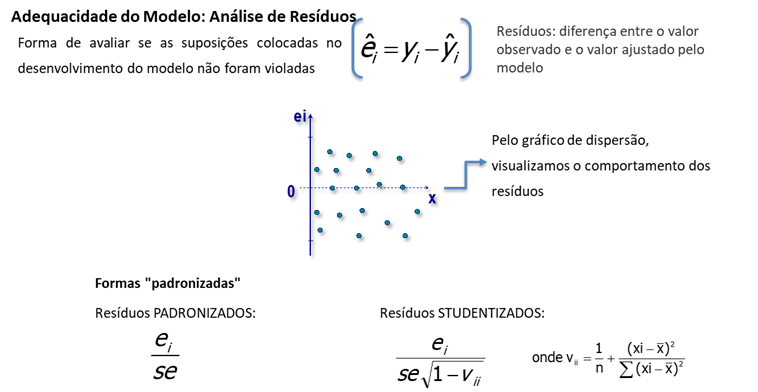



    Gráficos de Diagnóstico dos Resíduos
    
    => Residuals vs Fitted - indica a existência de padrões não lineares nos resíduos. Uma das suposições matemáticas na construção de um modelo usando Mínimos Quadrados é que os dados podem ser ajustados por uma linha. Se essa suposição for válida e os dados puderem ser ajustados por um modelo linear, uma linha aproximadamente horizontal sem padrões aparecerá no gráfico.

    => Normal Q-Q - examina se os resíduos são normalmente distribuídos. É bom que os pontos residuais sigam a linha reta.

    => Homoscedasticidade - verifica a homogeneidade de variância dos resíduos. A linha horizontal com pontos igualmente dispersos é uma boa indicação de homoscedasticidade.
  
    => Distância de Cook mede a diferença entre um modelo de regressão com determinada observação e um modelo sem aquela observação.
    Ele faz isso para todas as observações e nos informa, portanto, o quanto cada caso influencia a estimativa do modelo

    Antes de se construir os gráficos, em primeiro construir-se-á o modelo de resíduo para cada diagnóstico.

In [ ]:
# Construção de diagnóstico para os gráficos

modelo_ajust_y = model_fim.fittedvalues # Valores do modelo ajustados na base treino

modelo_residuos = model_fim.resid # Residuos

modelo_norm_resid = model_fim.get_influence().resid_studentized_internal # Residuos normalizados

modelo_norm_resid_abs = np.sqrt(np.abs(modelo_norm_resid)) # Quadrados dos residuos normalizados

modelo_outliers = model_fim.get_influence().hat_matrix_diag # Outliers

distancia_cook = model_fim.get_influence().cooks_distance[0] # Distancia de Cook


In [ ]:
modelo_ajust_y

In [ ]:
modelo_residuos

In [ ]:
modelo_norm_resid

In [ ]:
# um dataframe com a variável observado e estimado pelo modelo

dataframe = pd.concat([y_train, modelo_ajust_y], axis=1)

In [ ]:
dataframe

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(y_train_pred ,y_train, marker='.')
plt.xlabel("Observado")
plt.ylabel("Estimado");


In [ ]:
### Teste de Linearidade
### Nestes gráficos a presença de um padrão nos resíduos pode indicar um problema com algum aspecto do modelo linear.
plot_lm_1 = plt.figure()
plot_lm_1 = sb.residplot(data=dataframe, x=dataframe.columns[-0], y=modelo_ajust_y,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
### Teste de Normalidade
### O gráfico de resíduos pode ser usado para verificar visualmente a suposição de normalidade.
### Sendo que para que se aceite que os resíduos estão normalmente distribuidos deve seguir aproximadamente uma linha reta.

plot_lm_2  = sm.qqplot(modelo_norm_resid, line='45')
plt.show()


    Teste de normalidade dos resíduos Shapiro-Wilk Test Teste de hipótese:

    H0: Distribuição = Normal H1: Distribuição <> Normal

    Erro de decisâo: 0,05 ou 5%

    Critério de decisâo:
        Se p-value < erro de decisão então rejeito H0.
        Se p-value >= erro de decisão então não rejeito H0

In [ ]:
shapiro_test = stats.shapiro(modelo_norm_resid)
shapiro_test
#(statistic, p-value)

###     Qual a sua conclusão?
    

    Quando a analise de residuos revela que o modelo utilizado nao se ajusta aos dados de maneira satisfatoria,
    existem estrategias que podem ser utilizadas para melhorar o ajuste:
    
    #. Transformacao de variaveis: Aplicar alguma funcao em Y, como logaritmo ou raiz quadrada.

    #. Adicao de termo quadrático: X^2

    #. Adicao de interacao entre variaveis: X1*X2

    #. Escolha de outro tipo de modelo linear: polinomial, segmentado, de efeitos aleatorios

    #. Outra escolha eh trabalhar com Regressoes Penalizadas(Ridge e Lasso)

    #. Escolha de outro tipo de modelo nao necessariamente linear: GLMs, modelos nao-lineares

    #. Escolha de outros algoritmos como Árvore de Regressão, SVM, KNN, Modelos Esemble, Redes Neurais



In [ ]:
# Exemplo de trasformação de uma variável

imoveis['raiz_valor'] = np.sqrt(imoveis['Valor'])

In [ ]:
# Histograma da variável Valor  Variável target / Variável Dependente / Supervisionar

plt.hist(imoveis['raiz_valor'], bins=20)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title('Histograma raiz_valor')

### como pontuar a base teste

In [ ]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)
# Predict the y values corresponding to X_test_sm
y_pred = model_fim.predict(X_test_sm)

In [ ]:
y_pred

## Regressão linear múltipla

## Utilizando a biblioteca scikit-learn

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html


    O scikit-learn é uma biblioteca da linguagem Python desenvolvida especificamente para aplicação prática de machine learning.
    
    Esta biblioteca dispõe de ferramentas simples e eficientes para análise preditiva de dados, é reutilizável em diferentes situações, possui código aberto, sendo acessível a todos e foi construída sobre os pacotes NumPy, SciPy e matplotilib.
    
    Uma das melhores opções para aplicação prática de machine learning é através da linguagem Python.
    
    Um dos fatores que trás destaque a linguagem são justamente suas bibliotecas e pacotes, que proporcionam muita simplicidade as aplicações, além de garantir scripts descomplicados e eficientes. Dentre estes pacotes, temos o NumPy e o Pandas como os principais para a preparação dos dados, e o scikit-learn, ou apenas sklearn, sendo o mais utilizado para efetiva criação de modelos de machine learning.

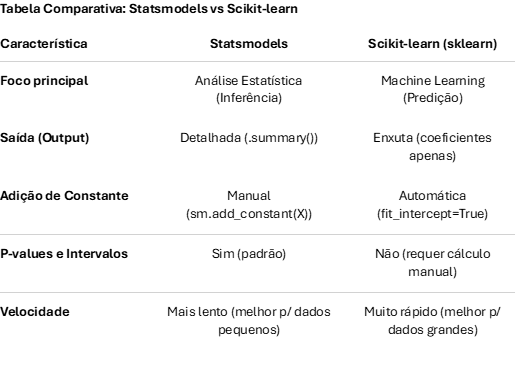

In [ ]:
#Separando os dados
# X = df.drop(['target'], axis = 1)

X = imoveis[['Area','Suites', 'IA', 'Semruido', 'Vista', 'Andar','AV100m','DistBM']]
y = imoveis[['Valor']]

In [ ]:
X

In [ ]:
X.columns

In [ ]:
# Regressão linear múltipla
from sklearn.linear_model import LinearRegression

#Criando um Objeto de Regressão Linear
lr = LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split

#Separando os dados de Treino e Teste
# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 17)

In [ ]:
#Treinando o Modelo
lr.fit(X_train,y_train)

In [ ]:
# Primeiro, vamos olhar o Intercepto e os Coeficientes da Regressão.

print('Intercepto:', lr.intercept_)


In [ ]:
print('Coeficientes:',lr.coef_)

In [ ]:
#coeff_df = pd.DataFrame(np.transpose(lr.coef_),X.columns,X.columns==['Coefficient'])
#coeff_df


coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients.columns=(['Variáveis','coefficients'])

coefficients

In [ ]:
# Calculando o valor predito da variável resposta na amostra teste
y_test_pred = lr.predict(X_test)

In [ ]:
#Verificando o resultado
r_sq = lr.score(X, y)
print('Coeficiente de Determinação (R²):', r_sq)

#### Performance do Modelo


In [ ]:
# Importar a biblioteca
# Medidas de erro
# Mean Absolute Error (MAE) é a média do valor absoluto dos erros.
# Erro Quadrático Médio (MSE) é a média dos erros quadráticos
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
# Utilizado quando vamos comparar vários modelos

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# Calculando o valor predito da variável resposta na amostra treino
y_test_pred = lr.predict(X_test)

In [ ]:
y_test_pred

In [ ]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático:',rmse_Reg_lin )


####  A partir desta parte testar de outros algoritmos
    como Árvore de Regressão, SVMRegressor, KNNRegressor, Modelos Esemble para variáveis target numeríca , Redes Neurais


    ==>Escolher qual o algoritmo tem o melhor desempenho: Menor erro quadrático médio

    ==> Vale ressaltar que a escolha do algoritmo tem que ser realizado não somente com o desempenho mas também com o ambiente que será implementado e como será utilizado.

## Arvore de Regressão

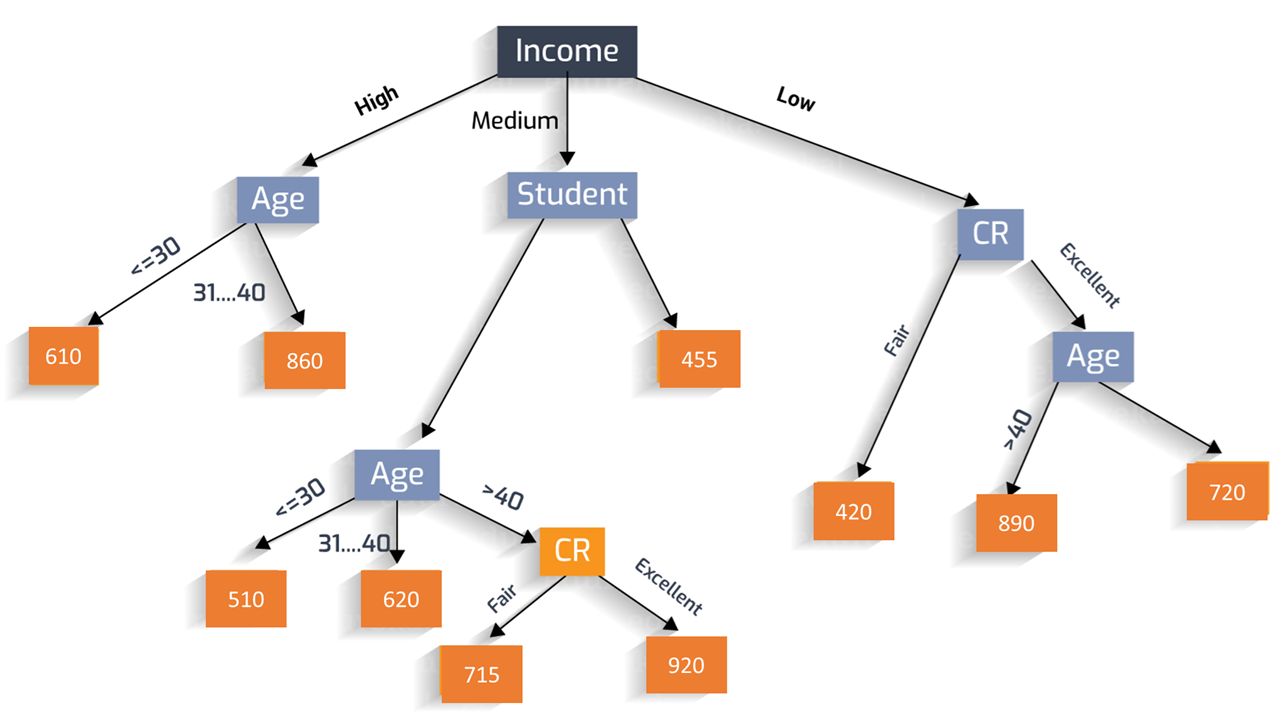

In [ ]:
# Import the necessary modules and libraries

from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree


https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

In [ ]:
# Importar as bibliotecas
from sklearn.model_selection import train_test_split

# random_state é o número aleatório usado para sortear as amostras. O seu uso é opcional.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.05, random_state = 17)

In [ ]:
# Fit regression model
model_2 = DecisionTreeRegressor(max_depth=4,min_samples_split=10,random_state=17,criterion='squared_error')

In [ ]:
model_2

In [ ]:
cols = X_train.columns

In [ ]:
cols

In [ ]:
# Treinando o modelo de arvore de decisão:

model_2.fit(X_train, y_train)

In [ ]:
X_train

In [ ]:

from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
input_features=['Area','Suites', 'IA', 'Semruido', 'Vista', 'Andar','AV100m','DistBM']
fig = plt.figure(figsize=(14,18))
plot_tree(model_2, fontsize=6,filled=True, feature_names=input_features )

In [ ]:
for caracteristica, score in zip(X_train, model_2.feature_importances_):
  print('caracteristica {} e Importância {}'.format(caracteristica, score*100))

In [ ]:
# Aplicando o algoritmo na base teste

y_test_regtree  = model_2.predict(X_test)

In [ ]:
y_test_regtree

In [ ]:
y_test

In [ ]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Arv_Regr  = (np.sqrt(mean_squared_error(y_test, y_test_regtree))).round(2)

print('Erro médio quadrático da Árvore de Regressão:',rmse_Arv_Regr  )


### lembrando .. e qual era da Regressão Linear?

In [ ]:
#Erro médio quadrático da raiz (RMSE) é a raiz quadrada da média dos erros quadráticos
rmse_Reg_lin  = (np.sqrt(mean_squared_error(y_test, y_test_pred))).round(2)

print('Erro médio quadrático da Regressão Linear:',rmse_Reg_lin )
